In [1]:
import imageio.v3 as iio
import random
import numpy as np
from metaworld.policies.sawyer_stick_pull_v2_policy import SawyerStickPullV2Policy as p
import metaworld

curr_name = 'safe-stick-pull'
ml1 = metaworld.ML1(curr_name) # Construct the benchmark, sampling tasks
env = ml1.train_classes[curr_name](render_mode='rgb_array') 
task = random.choice(ml1.train_tasks)
env.set_task(task)  
env._partially_observable = False
env._freeze_rand_vec = False
obs, info = env.reset()
done = False
rewards = []
costs = []
qpos = []
states = []

policy = p()

# List to store frames
frames = []

i = 0
while not done:
    action = policy.get_action(obs)
    # action = env.action_space.sample()
    # action = np.array([0, 0, 0, 0])
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()  # Capture frame as RGB array
    frames.append(frame)  # Add frame to the list
    done = terminated or truncated or (int(info['success']) == 1)
    i += 1
    rewards.append(reward)
    costs.append(info['unscaled_cost'])
    qpos.append(env.data.qpos.copy())
    states.append(obs[18:21])

# Save the video
iio.imwrite("basketball_simulation.mp4", frames, fps=30)  # Adjust fps if necessary

env.close()


/home/austinc/.conda/envs/continual-rl/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float64
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/austinc/projects/safe-crl/code/Metaworld/metaworld/policies/policy.py:42: UserWarning: Constant(s) may be too high. Environments clip response to [-1, 1]
  warnings.warn(


ValueError: operands could not be broadcast together with shapes (60,) (53,) (53,) 

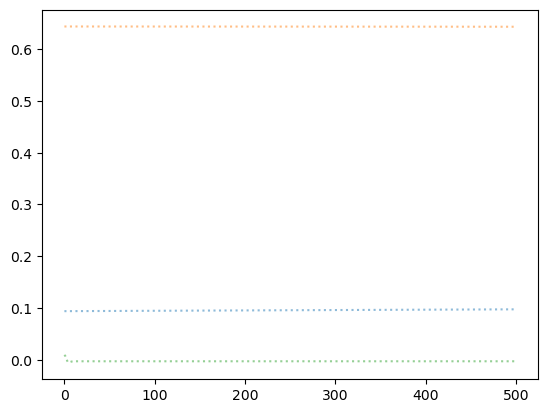

In [4]:
import matplotlib.pyplot as plt
plt.plot(np.array(states), alpha=0.5, linestyle=':')


In [5]:
print(sum(rewards))
print(sum(costs))

1743.2428969149491
0.0


Text(0.5, 0, 'Simulation Timestep')

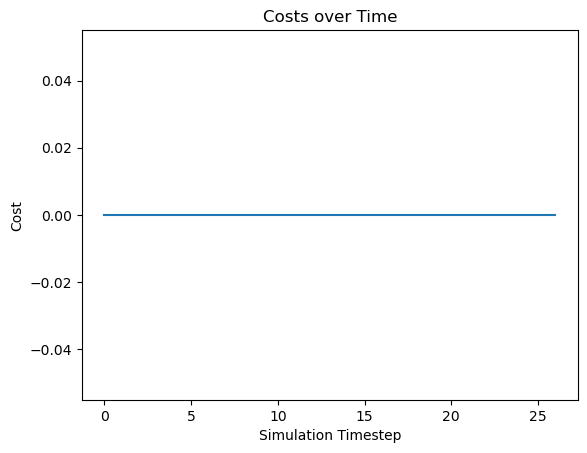

In [ ]:
import matplotlib.pyplot as plt

plt.title("Costs over Time")
plt.plot(costs)
plt.ylabel("Cost")
plt.xlabel("Simulation Timestep")